In [1]:
import pygmo as pg
import numpy as np
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from topological_insulator import Problem
from mean_field_problem import MeanFieldProblem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

t = 1
delta = -1.143

In [3]:
location = "bulk"
occupations_old = np.zeros(24)
mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=t, U=0, delta=delta, occupations= occupations_old
    )
problem = Problem(
        structure_path=mean_field_problem.structure_path, 
        structure_name=mean_field_problem.structure_name)
mean_field_problem._set_eigenvalues(problem, occupations_old, debug=True)
problem.setup(
    N_r = 10,
    N_k = 200,
    location = location,
    BZ = "reduced"
)
problem.run(
    H_type="reciprocal"
)

{'onsite_energy': {'A': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'B': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': 2.143, 't_pp_pi': -0.14300000000000002, 'delta_heavy': 0, 'delta_light': 0}, 'C': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': 2.143, 't_pp_pi': -0.14300000000000002, 'delta_heavy': 0, 'delta_light': 0}}, 'kane_mele_soc': {'A': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}, 'B': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}, 'C': {'lambda_ss': 0, 'lambda_sp': 0, 'lambda_pp': 0}}, 'chadi_soc': {'A': {'Delta_ss': 0, 'Delta_sp': 0, 'Delta_pp': -5}}, 'interaction': {'A': {'U_s': 0, 'U_p': 0, 'n_s_up': 0, 'n_s_down': 0, 'n_px_up': np.float64(0.0), 'n_px_down': np.float64(0.0), 'n_py_up': np.float64(0.0), 'n_py_down': np.float64(0.0), 'n_pz_up': np.float64(0.0), 'n_pz_down': np.float64(0.0)}}}
{'onsite_energy': {'B': {'E_s': 0, 'E_p': 0}}, 'nn_hopping': {'A': {'t_ss_sigma': 0, 't_sp_sigma': 0, 't_pp_sigma': 2.143, 't_pp_pi': -0.14300000000000002}, 'C': {'t_ss_sigma': 

In [4]:
g = problem.geometry
tb_bulk = problem.hamiltonian[location]["tight_binding"]
invariants = problem.hamiltonian["bulk"]["topological_invariants"]

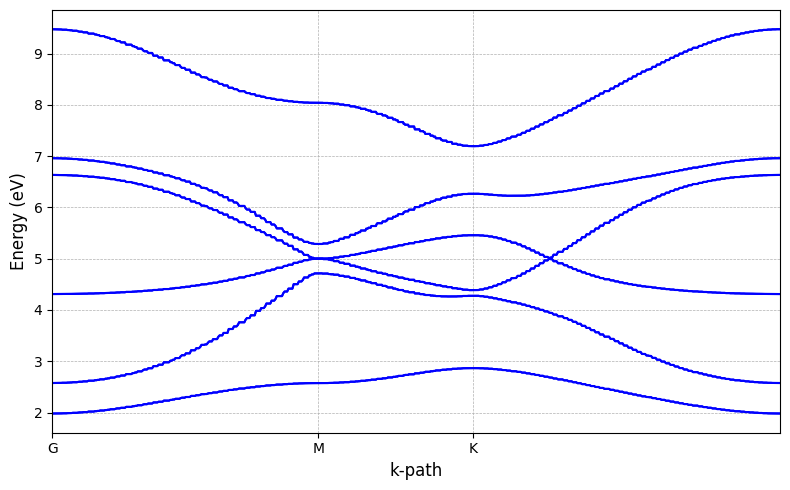

In [5]:
j_3_2 = [i for i in range(8, 24)]
tb_bulk.plot_band_structure(g, bands=j_3_2)

In [6]:
mean_field_problem.setup(11, 1, 0.05, T = 300, N_h = 2)

In [7]:
E, DOS = mean_field_problem.density_of_states(
    g, tb_bulk, invariants, mean_field_problem.E_max, 
    mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)

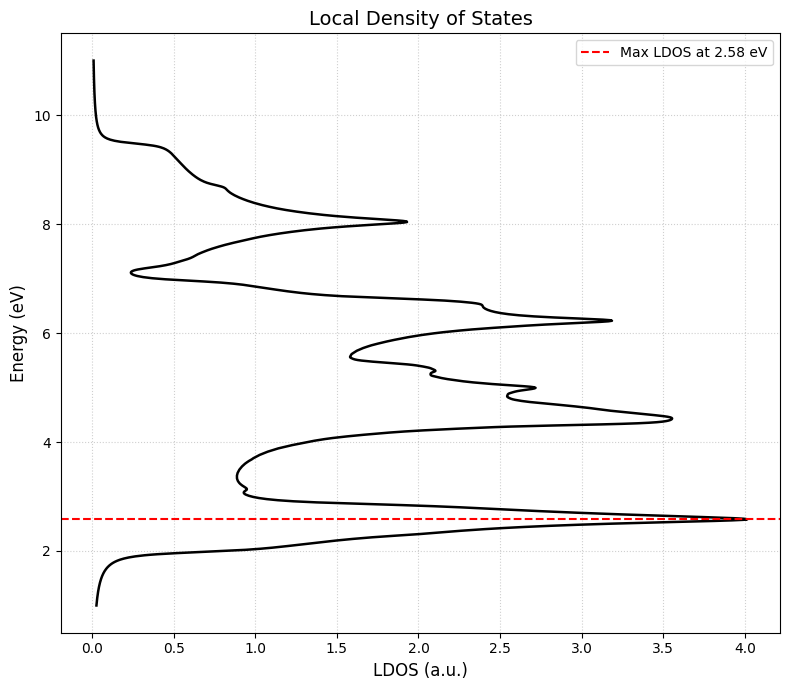

In [8]:
invariants.plot_density_of_states(E, DOS)

In [9]:
mu = mean_field_problem.find_chemical_potential(E, DOS, 3, 300)
print(mu)

6.398289733267845


In [14]:
U = 3
N_h = 3
location = "bulk"
tol = 1e-4
occupations_old = np.zeros(24)
converged_e, converged_h = False, False
counter = 0
results = {}
while not converged_e:
    mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=t, U=U, delta=delta, occupations= occupations_old
    )
    mean_field_problem.setup(10, -10, 0.05, T = 300, N_h = N_h)
    problem = Problem(
            structure_path=mean_field_problem.structure_path, 
            structure_name=mean_field_problem.structure_name)
    mean_field_problem._set_eigenvalues(problem, occupations_old)
    problem.setup(
        N_r = 10,
        N_k = 250,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    g = problem.geometry
    tb_bulk = problem.hamiltonian[location]["tight_binding"]
    invariants = problem.hamiltonian["bulk"]["topological_invariants"]
    E, DOS = mean_field_problem.density_of_states(
        g, tb_bulk, invariants, mean_field_problem.E_max, 
        mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)
    mu_max = np.max(E) + 10
    mu_min = np.min(E) - 10
    mu = mean_field_problem.find_chemical_potential(
        E, DOS, mean_field_problem.N_h, mean_field_problem.T, 
        mu_max, mu_min
    )
    occ_e, occ_h = mean_field_problem.get_occupations(
        g, tb_bulk, E, mu, mean_field_problem.T
    )
    results[counter] = occ_e
    diff_e = np.abs(occupations_old - occ_e)
    converged_e = np.all(diff_e < tol)
    diff_h = np.abs(np.sum(occ_h) -N_h)
    converged_h =  np.all(diff_h < tol)
    print(counter, diff_h, diff_e)
    occupations_old = occ_e
    counter +=1

Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
0 0.028994510832613063 [1.         1.         0.52533349 0.52533349 0.62136781 0.62136781
 0.74918594 0.74918594 1.         1.         0.52533343 0.52531608
 0.62136775 0.62135041 0.74916853 0.74918587 1.         1.
 0.66927433 0.6692918  0.47928577 0.47930325 0.74949733 0.74947985]
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!
1 0.05274180656871863 [1.         1.         0.10099656 0.10099781 0.13471888 0.13471796
 0.14877866 0.14877836 1.         1.         0.10099307 0.10098039
 0.13471415 0.13470053 0.14876123 0.14877352 1.         1.
 0.14831668 0.1483297  0.08947613 0.08948962 0.15668805 0.15667579]
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eige

In [15]:
np.savetxt(f"results/occupations_symmetric_U={U}_delta={delta}.txt", occ_e)

In [16]:
occ_e

array([1.        , 1.        , 0.42269625, 0.42269624, 0.48901679,
       0.4890168 , 0.59858399, 0.59858399, 1.        , 1.        ,
       0.42269626, 0.42269624, 0.48901681, 0.4890168 , 0.59858399,
       0.59858401, 1.        , 1.        , 0.52482321, 0.52482324,
       0.38829765, 0.38829767, 0.59399223, 0.59399221])